# DESN Real-Time ENSO Forecast

Pipeline:
1. **Data loading** — full 1958–2026 dataset; train/val split
2. **Hyperparameter tuning** *(optional, skipped by default)*
3. **Train on 1979–2020**, evaluate skill on two validation sets
4. **Skill comparison** vs XRO (past / recent val sets)
5. **Real-time rolling forecast** from the latest time point

In [2]:
import warnings
warnings.filterwarnings("ignore")
from RCENSO import *
from XRO import *
import numpy as np
import reservoirpy as rpy
import xarray as xr
rpy.verbosity(0)
%config InlineBackend.figure_format = 'retina'

# ── Global settings ──────────────────────────────────────────────────────────
SKIP_TUNING = True          # Set False to enable hyperparameter tuning
TUNE_RECENT_WEIGHT = 0.5    # Weight of val(recent) in tuning score; past weight = 1 - this
FORECAST_STEPS = 21         # Real-time forecast horizon (months)
REALTIME_START = '2026-03-01'  # Latest initialisation month
PLOT_MODE = 'Nino34'        # Climate mode to plot in the real-time forecast figure
NMEMBERS = 1                # Ensemble members (increase for better estimates)

climate_modes = ['Nino34', 'WWV', 'NPMM', 'SPMM', 'IOB', 'TNA', 'ATL3', 'IOD', 'SIOD', 'SASD']

## 1. Data Loading

Three temporal splits:
- **Training**: 1979–2020  
- **Val (past)**: 1958–1978 (pre-training hindcast period)  
- **Val (recent)**: 2021–2026 (out-of-sample)

In [3]:
# Load full dataset 1958–2026
ds_full = xr.open_dataset('oras5_indices_1958-2026.nc', engine='netcdf4')
ds_full = standardize_time_to_month_start(ds_full)
ds_full = ds_full[['Nino34', 'WWV'] + [v for v in ds_full.data_vars if v not in ('Nino34', 'WWV')]]

# Training dataset (1979–2020) — used to build the full TS matrix
train_ds = ds_full.sel(time=slice('1979-01-01', '2020-12-01'))

# Validation datasets
val_past_ds  = ds_full.sel(time=slice('1958-01-01', '1978-12-01'))
val_recent_ds = ds_full.sel(time=slice('2021-01-01', '2026-12-01'))

# TS matrix for the training window only (used to train models)
TS_train = train_ds.to_array().values.T          # (T_train, n_vars)
tl = TS_train.shape[0]                           # training length

# TS matrices for validation windows
TS_past   = val_past_ds.to_array().values.T
TS_recent = val_recent_ds.to_array().values.T

print(f"Training length : {tl} months  ({train_ds.time.values[0]} – {train_ds.time.values[-1]})")
print(f"Val (past)      : {TS_past.shape[0]} months")
print(f"Val (recent)    : {TS_recent.shape[0]} months")

Training length : 504 months  (1979-01-01T00:00:00.000000000 – 2020-12-01T00:00:00.000000000)
Val (past)      : 252 months
Val (recent)    : 63 months


## 2. Hyperparameter Configuration

Default hyperparameters (from the paper).  
The tuning cell below will update these if `SKIP_TUNING = False`.

In [4]:
model_types = [r'DESN($n_l=1$)', r'DESN($n_l=2$)']

hypers = {
    model_types[0]: {
        'units': 20000,
        'lr': 1,
        'sr': 1,
        'rc_connectivity': 0.0,
        'input_connectivity': 0.10,
        'input_scaling': 1,
        'ridge': 5e-6,
        'noise_rc': 0.05,
        'noise_in': 0,
        'output_dim': TS_train.shape[1],
        'seed': None,
        'use_raw_input': True,
        'ip_reservoir': True,
    },
    model_types[1]: {
        'units': [20000, 12000],
        'lr': [1, 1],
        'sr': [1, 1],
        'rc_connectivity': [0, 0],
        'input_connectivity': [0.1, 0.1],
        'input_scaling': [1, 1],
        'ridge': 5e-6,
        'noise_rc': [0.05, 0],
        'noise_in': [0, 0],
        'output_dim': TS_train.shape[1],
        'seed': None,
        'deep': True,
        'deep_ip_list': [True, False],
    },
}

print("Default hyperparameters loaded.")

Default hyperparameters loaded.


## 3. Hyperparameter Tuning *(optional)*

**Strategy**: layer-by-layer, using a **Genetic Algorithm** for fine-tuning around the default values.

- **Layer 1**: GA optimises `input_connectivity` ∈ [0.05, 0.20], `noise_rc` ∈ [0.01, 0.10], `ridge` ∈ [5e-7, 5e-5] (log-scale).
- **Layer 2** (built on best L1): GA optimises `input_connectivity_L2` ∈ [0.05, 0.20] and `units_L2` ∈ [6000, 20000].

GA settings (`GA_POP`, `GA_GENS`, `GA_ELITE`, `GA_MUT_SIGMA`) are tunable at the top of the cell.  
Objective = weighted Nino34 corr at lead 1–12 across both validation sets (`TUNE_RECENT_WEIGHT`).  
Set `SKIP_TUNING = True` (top cell) to skip entirely.

In [5]:
def _val_corr_nino34(trained_models, steps=20, tp_order=2):
    """Weighted mean Nino34 corr (lead 1–12) across both validation sets.
    TUNE_RECENT_WEIGHT controls the weight of val(recent); past weight = 1 - it.
    """
    w_recent = TUNE_RECENT_WEIGHT
    w_past   = 1.0 - w_recent
    scores = []
    for TS_val, w in [(TS_past, w_past), (TS_recent, w_recent)]:
        if w == 0:
            continue
        TP_val = get_RCTP(TS_val, steps=steps, omega=2*np.pi/12, order=tp_order, bias=0)
        Ypred_mean, _ = TPRC_Forecast_Ensemble(
            trained_models, TS_val, TP_test=TP_val, steps=steps, noise_ini=0.0)
        Ytest_arr = np.hstack((TS_val, TP_val[:-steps]))
        R, _ = ndforecast_skill(Ypred_mean, Ytest_arr, showdim=0, ismv3=True, wl=0)
        scores.append(w * np.mean(R[1:13]))
    return sum(scores)


# ── Genetic Algorithm fine-tuning ─────────────────────────────────────────────
# Each gene is a float in [0, 1] that linearly maps to the parameter's search
# range. Ranges are narrow, centred on the default values (±perturbation only).

GA_POP   = 12    # population size (keep small: each eval = 1 training run)
GA_GENS  = 8     # number of generations
GA_ELITE = 2     # elite individuals carried forward unchanged
GA_MUT_SIGMA = 0.15   # Gaussian mutation std (in gene space [0,1])
GA_CROSS_PROB = 0.6   # crossover probability per gene
GA_SEED  = 42


def _decode_l1(gene):
    """Map gene vector [0,1]^3 → (input_connectivity, noise_rc, ridge).
    Ranges: ±50% around defaults, log-scale for ridge.
    """
    ic    = 0.05  + gene[0] * 0.15          # [0.05, 0.20]
    noise = 0.01  + gene[1] * 0.09          # [0.01, 0.10]
    # ridge in log-space: default 5e-6, range [5e-7, 5e-5]
    ridge = 10 ** (-6.3 + gene[2] * 2.0)   # ≈ [5e-7, 5e-5]
    return ic, noise, ridge


def _decode_l2(gene, best_l1):
    """Map gene vector [0,1]^2 → (input_connectivity_l2, units_l2)."""
    ic2 = 0.05 + gene[0] * 0.15            # [0.05, 0.20]
    u2  = int(round((6000 + gene[1] * 14000) / 1000) * 1000)  # [6k,20k] step 1k
    u2  = min(u2, 20000)
    return ic2, u2


def _ga_evolve(n_genes, decode_fn, eval_fn, pop_size, n_gens,
               n_elite, mut_sigma, cross_prob, rng, label):
    """Minimalist GA: real-valued genes in [0,1]^n_genes.
    Uses tournament selection, uniform crossover, Gaussian mutation.
    Returns best_gene, best_score.
    """
    pop = rng.uniform(0, 1, size=(pop_size, n_genes))
    fitness = np.full(pop_size, -np.inf)

    for gen in range(n_gens):
        # Evaluate unevaluated individuals
        for i in range(pop_size):
            if fitness[i] == -np.inf:
                fitness[i] = eval_fn(pop[i])

        best_idx = np.argmax(fitness)
        print(f"  [{label}] Gen {gen+1}/{n_gens}  "
              f"best={fitness[best_idx]:.4f}  params={decode_fn(pop[best_idx])}")

        if gen == n_gens - 1:
            break

        # Sort by fitness descending
        order = np.argsort(fitness)[::-1]
        new_pop = pop[order[:n_elite]].copy()  # elites
        new_fit = fitness[order[:n_elite]].copy()

        # Fill rest of population via tournament + crossover + mutation
        while len(new_pop) < pop_size:
            # Tournament selection (size 3)
            def tournament():
                idx = rng.choice(pop_size, size=3, replace=False)
                return pop[idx[np.argmax(fitness[idx])]].copy()

            p1, p2 = tournament(), tournament()
            # Uniform crossover
            mask = rng.uniform(size=n_genes) < cross_prob
            child = np.where(mask, p1, p2)
            # Gaussian mutation
            child += rng.normal(0, mut_sigma, size=n_genes)
            child = np.clip(child, 0, 1)
            new_pop = np.vstack([new_pop, child[None]])
            new_fit = np.append(new_fit, -np.inf)  # will be evaluated next gen

        pop = new_pop
        fitness = new_fit

    best_idx = np.argmax(fitness)
    return pop[best_idx], fitness[best_idx]


if not SKIP_TUNING:
    rng = np.random.default_rng(GA_SEED)

    # ── Layer 1 GA ────────────────────────────────────────────────────────────
    print("=" * 60)
    print(f"LAYER 1 GA TUNING  "
          f"(recent_w={TUNE_RECENT_WEIGHT}, pop={GA_POP}, gens={GA_GENS})")
    print("=" * 60)

    def _eval_l1(gene):
        ic, noise, ridge = _decode_l1(gene)
        h = {**hypers[model_types[0]],
             'input_connectivity': ic, 'noise_rc': noise, 'ridge': ridge}
        models_tmp, _ = TPRC_Train_Ensemble(TS_train, tl, dl=0, hypers=h, nmember=1)
        return _val_corr_nino34(models_tmp)

    best_gene_l1, best_score_l1 = _ga_evolve(
        n_genes=3, decode_fn=_decode_l1, eval_fn=_eval_l1,
        pop_size=GA_POP, n_gens=GA_GENS, n_elite=GA_ELITE,
        mut_sigma=GA_MUT_SIGMA, cross_prob=GA_CROSS_PROB,
        rng=rng, label='L1')

    ic_best, noise_best, ridge_best = _decode_l1(best_gene_l1)
    best_l1_params = {'input_connectivity': ic_best,
                      'noise_rc': noise_best, 'ridge': ridge_best}
    hypers[model_types[0]].update(best_l1_params)
    print(f"\nBest L1: ic={ic_best:.4f}, noise={noise_best:.4f}, "
          f"ridge={ridge_best:.2e}  (score={best_score_l1:.4f})")

    # ── Layer 2 GA ────────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print(f"LAYER 2 GA TUNING  (pop={GA_POP}, gens={GA_GENS})")
    print("=" * 60)

    def _eval_l2(gene):
        ic2, u2 = _decode_l2(gene, best_l1_params)
        h2 = {**hypers[model_types[1]],
              'input_connectivity': [ic_best, ic2],
              'noise_rc': [noise_best, 0],
              'ridge': ridge_best,
              'units': [20000, u2]}
        models_tmp2, _ = TPRC_Train_Ensemble(TS_train, tl, dl=0, hypers=h2, nmember=1)
        return _val_corr_nino34(models_tmp2)

    best_gene_l2, best_score_l2 = _ga_evolve(
        n_genes=2, decode_fn=lambda g: _decode_l2(g, best_l1_params),
        eval_fn=_eval_l2,
        pop_size=GA_POP, n_gens=GA_GENS, n_elite=GA_ELITE,
        mut_sigma=GA_MUT_SIGMA, cross_prob=GA_CROSS_PROB,
        rng=rng, label='L2')

    ic2_best, u2_best = _decode_l2(best_gene_l2, best_l1_params)
    hypers[model_types[1]].update({
        'input_connectivity': [ic_best, ic2_best],
        'noise_rc': [noise_best, 0],
        'ridge': ridge_best,
        'units': [20000, u2_best],
    })
    print(f"\nBest L2: ic2={ic2_best:.4f}, units2={u2_best}  (score={best_score_l2:.4f})")

else:
    print("Hyperparameter tuning skipped (SKIP_TUNING=True).")

Hyperparameter tuning skipped (SKIP_TUNING=True).


## 4. Train DESN Ensemble on 1979–2020

In [6]:
trained_models = {}   # {model_type: list_of_esns}
TP_train = {}         # {model_type: TP array}

for mt in model_types:
    print(f"Training {mt} …")
    models, tp = TPRC_Train_Ensemble(
        TS_train, tl, dl=0, hypers=hypers[mt], nmember=NMEMBERS)
    trained_models[mt] = models
    TP_train[mt] = tp
    print(f"  Done. ({NMEMBERS} member(s))")

Training DESN($n_l=1$) …


Training ensemble members: 100%|██████████| 1/1 [00:29<00:00, 29.02s/it]


  Done. (1 member(s))
Training DESN($n_l=2$) …


Training ensemble members:   0%|          | 0/1 [00:00<?, ?it/s]

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Training ensemble members: 100%|██████████| 1/1 [03:21<00:00, 201.17s/it]

  Done. (1 member(s))


## 5. Validation Skill — Past (1958–1978) & Recent (2021–2026)

In [7]:
FORECAST_STEPS_SKILL = 20   # lead times used for skill evaluation

corr_val = {'past': {}, 'recent': {}}
rmse_val = {'past': {}, 'recent': {}}

for val_label, TS_val in [('past', TS_past), ('recent', TS_recent)]:
    TP_val = get_RCTP(TS_val, steps=FORECAST_STEPS_SKILL,
                      omega=2*np.pi/12, order=2, bias=0)

    all_preds = []
    for mt in model_types:
        Ypred_mean_mt, preds_mt = TPRC_Forecast_Ensemble(
            trained_models[mt], TS_val, TP_test=TP_val,
            steps=FORECAST_STEPS_SKILL, noise_ini=0.0)
        all_preds.append(preds_mt)

    # DESN ensemble mean across both architectures
    nm_fcst = np.concatenate(all_preds, axis=0)
    Ensemble_Fcst = nm_fcst.mean(axis=0)

    # Ytest for skill: need (T, n_vars+n_tp) — first n_vars columns are observations
    Ytest_val = np.hstack((TS_val, TP_val[:-FORECAST_STEPS_SKILL]))

    for i, mode in enumerate(climate_modes):
        R, rmse = ndforecast_skill(
            Ensemble_Fcst, Ytest_val, showdim=i, ismv3=True, wl=0)
        corr_val[val_label][mode] = R
        rmse_val[val_label][mode] = rmse

    print(f"{val_label:8s} — Nino34 corr @ lead 6: {corr_val[val_label]['Nino34'][6]:.3f}")

print("Validation skill computed.")

Forecasting with ensemble: 100%|██████████| 1/1 [02:11<00:00, 131.01s/it]


past     — Nino34 corr @ lead 6: 0.687


Forecasting with ensemble: 100%|██████████| 1/1 [00:41<00:00, 41.17s/it]

recent   — Nino34 corr @ lead 6: 0.766
Validation skill computed.


## 6. XRO Benchmark

In [8]:
XROac2 = XRO(ncycle=12, ac_order=2)
XROac2_fit = XROac2.fit_matrix(train_ds, maskb=['Nino34', 'IOD'])

corr_xro = {'past': {}, 'recent': {}}
rmse_xro = {'past': {}, 'recent': {}}

for val_label, val_ds_xro in [('past', val_past_ds), ('recent', val_recent_ds)]:
    xro_fcst = XROac2.reforecast(
        fit_ds=XROac2_fit, init_ds=val_ds_xro,
        n_month=FORECAST_STEPS_SKILL - 1, ncopy=1, noise_type='zero')
    Ypred_xro = xro_fcst.to_array().values.transpose(1, 0, 2)  # (T, n_vars, steps)

    # Build Ytest aligned with XRO output length
    TS_val = val_past_ds.to_array().values.T if val_label == 'past' else val_recent_ds.to_array().values.T
    n_steps_xro = Ypred_xro.shape[2]
    TP_val_xro = get_RCTP(TS_val, steps=n_steps_xro, omega=2*np.pi/12, order=2, bias=0)
    Ytest_val_xro = np.hstack((TS_val, TP_val_xro[:-n_steps_xro]))

    for i, mode in enumerate(climate_modes):
        R, rmse = ndforecast_skill(
            Ypred_xro, Ytest_val_xro, showdim=i, ismv3=True, wl=0)
        corr_xro[val_label][mode] = R
        rmse_xro[val_label][mode] = rmse

    print(f"XRO {val_label:8s} — Nino34 corr @ lead 6: {corr_xro[val_label]['Nino34'][6]:.3f}")

XRO past     — Nino34 corr @ lead 6: 0.761
XRO recent   — Nino34 corr @ lead 6: 0.753


## 7. Skill Comparison Plot (DESN vs XRO)

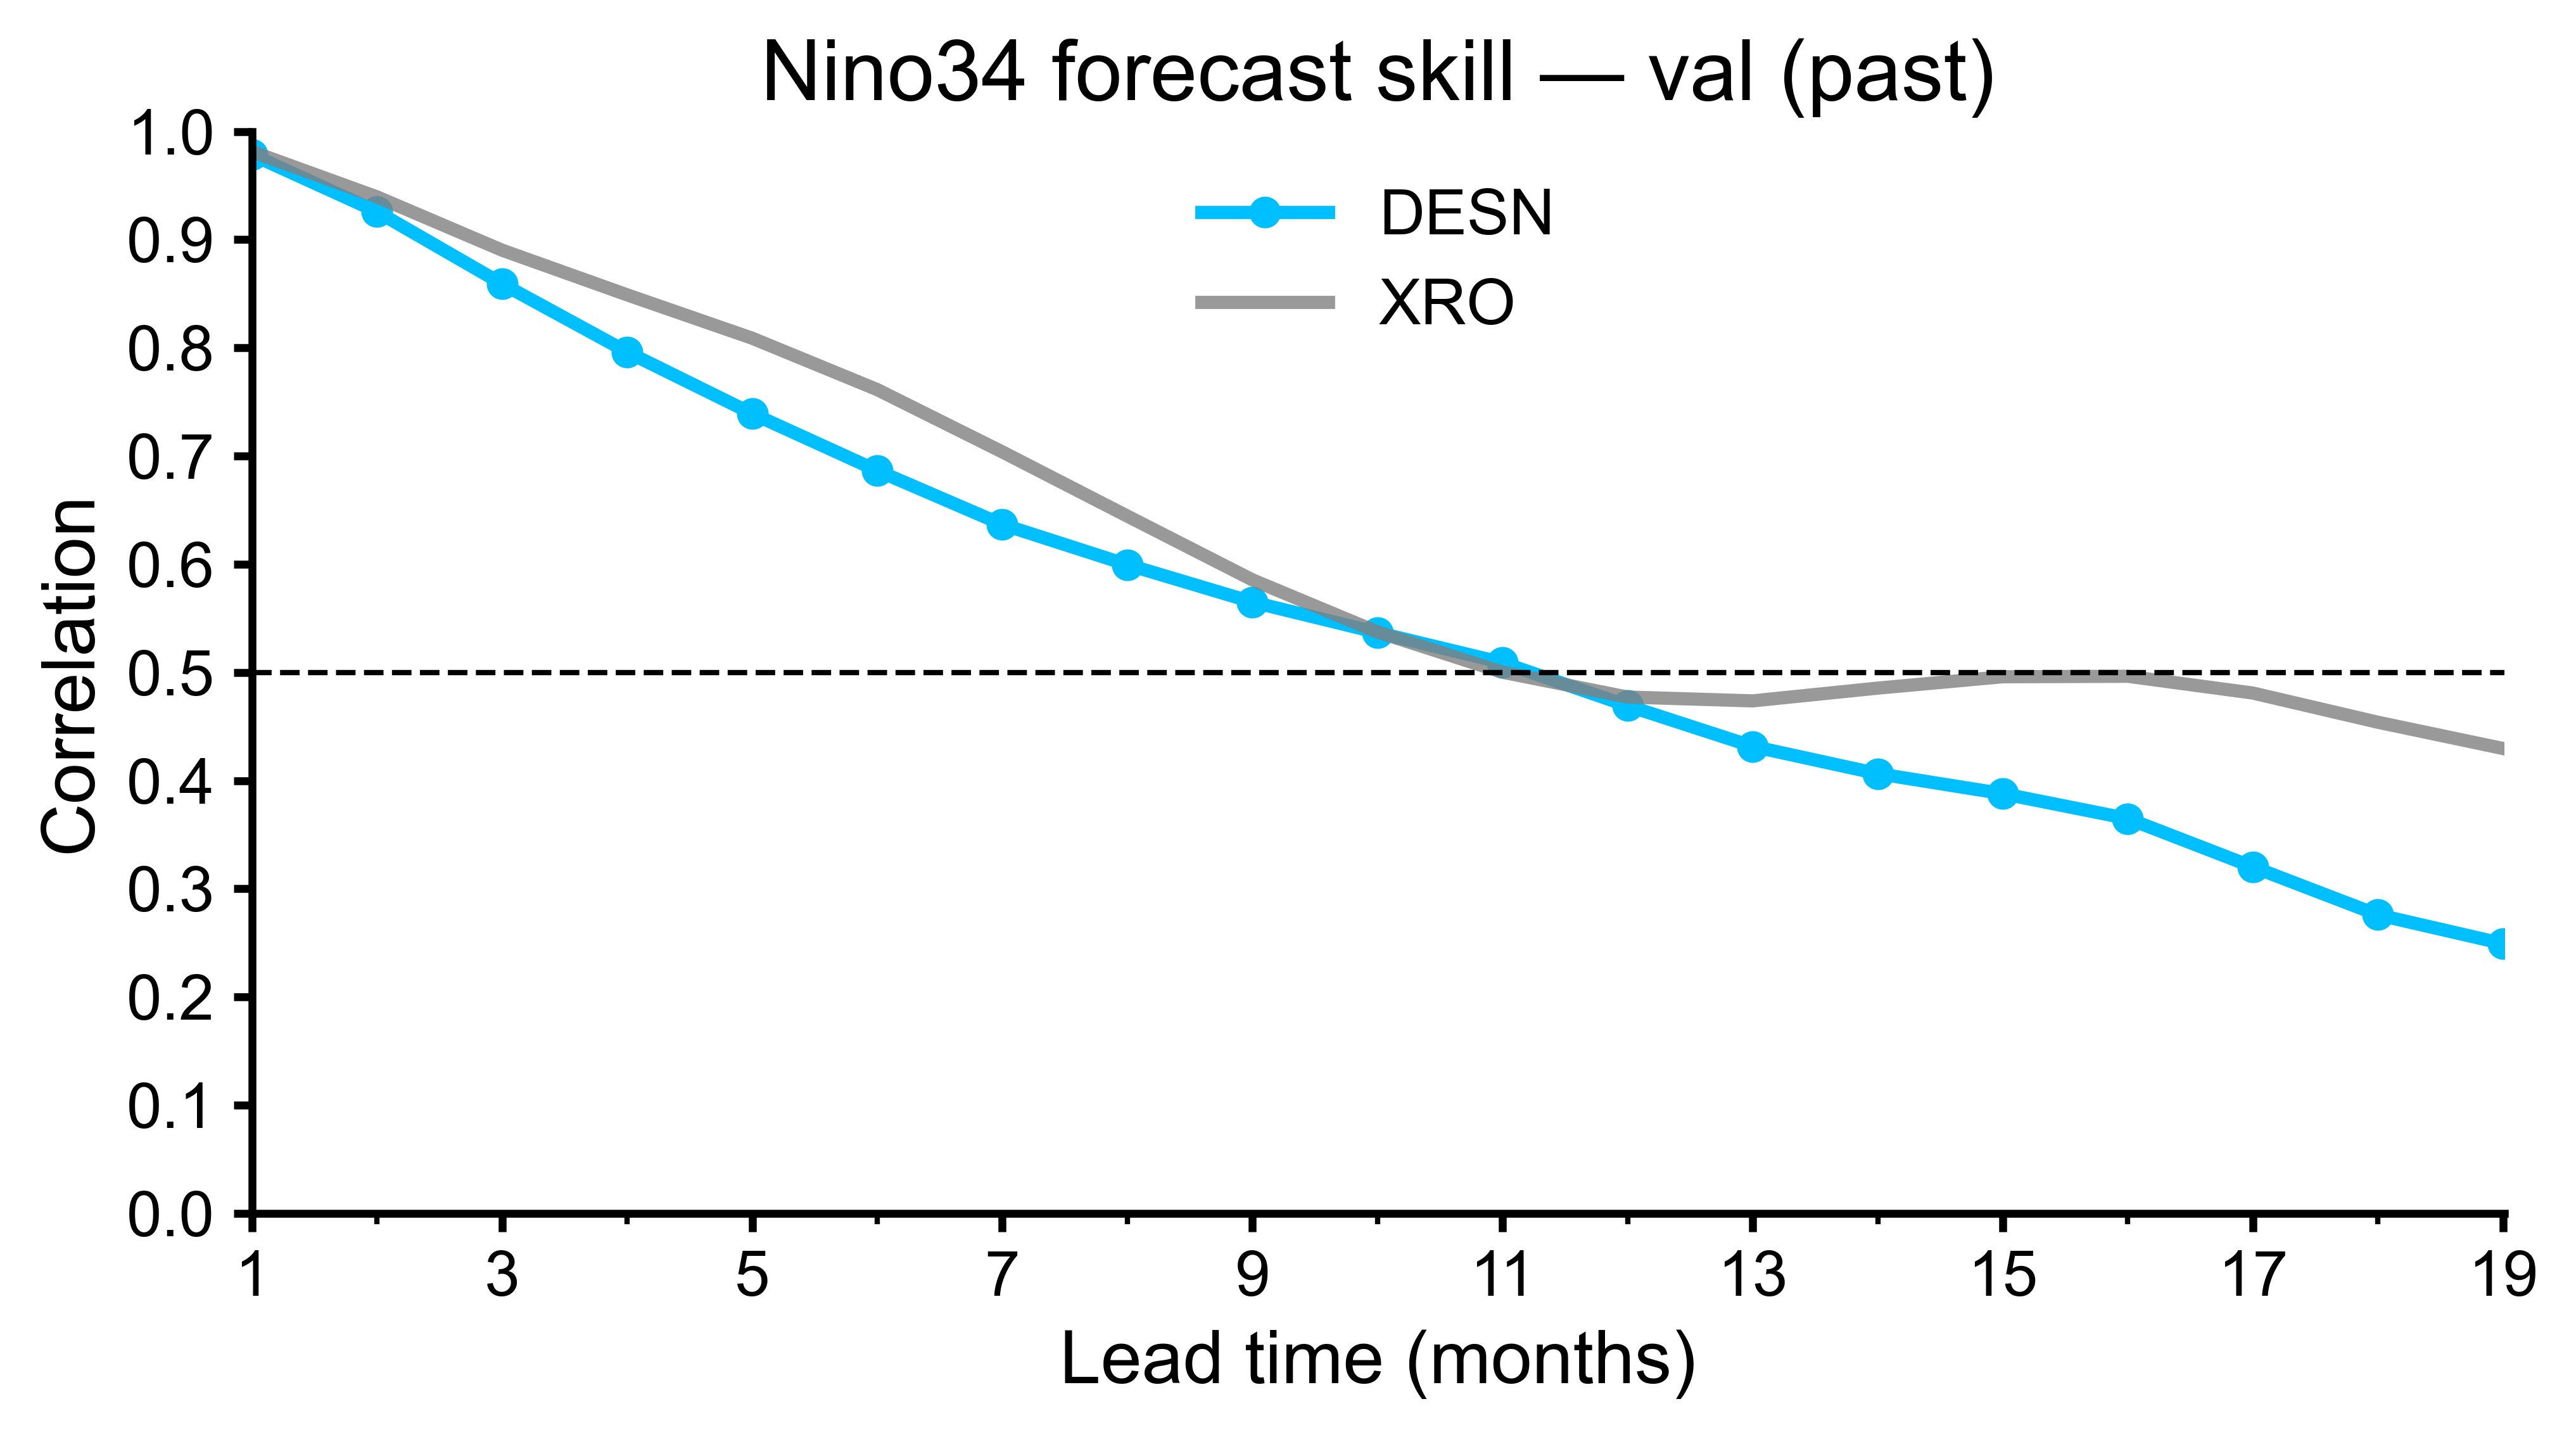

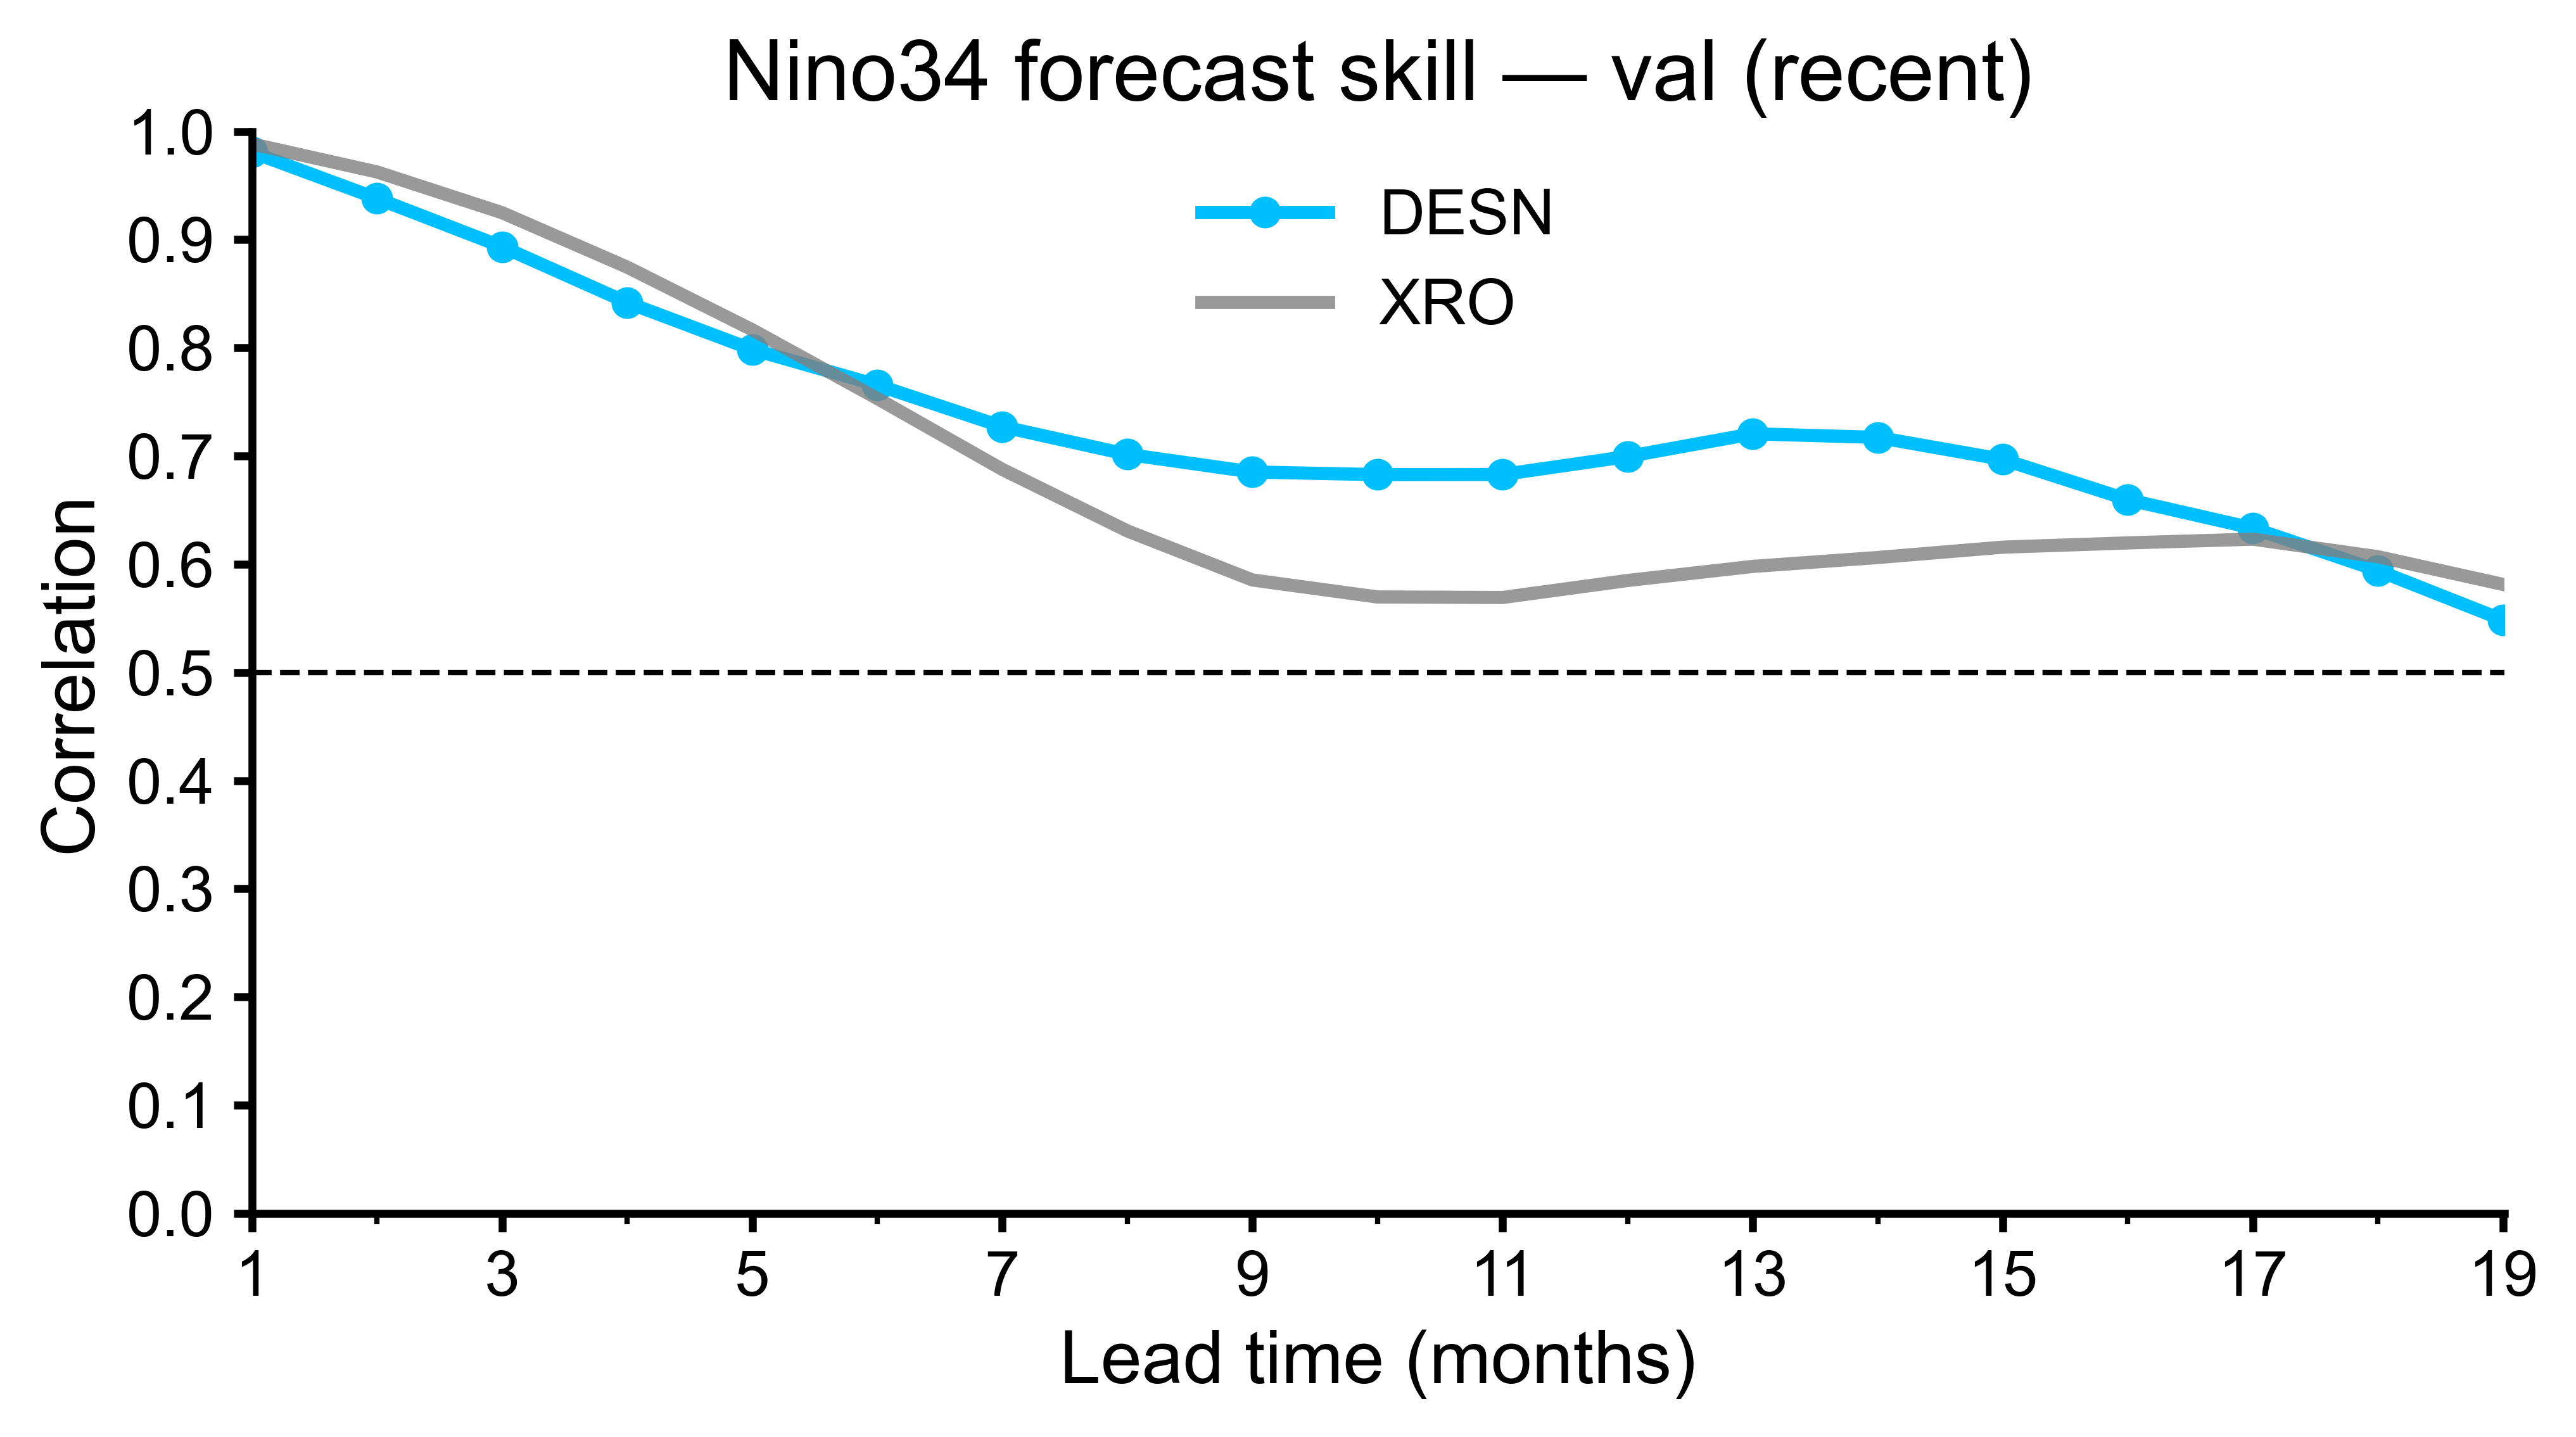

In [9]:
styles = {
    'DESN':  {'color': 'deepskyblue', 'marker': 'o', 'linewidth': 2.5, 'markersize': 5},
    'XRO':   {'color': 'gray',        'marker': '',  'linewidth': 2.5, 'alpha': 0.8},
}

for val_label in ['past', 'recent']:
    plot_main_skills_with_legend(
        skill_dict={'DESN': corr_val[val_label][PLOT_MODE],
                    'XRO':  corr_xro[val_label][PLOT_MODE]},
        styles=styles,
        grid_on=False,
        legend=True,
        legend_in_main=True,
        figsize=(7, 4),
        ylim=(0.0, 1.0),
        xlim=(1, FORECAST_STEPS_SKILL - 0.99),
        skill_name='Correlation',
        title=f'{PLOT_MODE} forecast skill — val ({val_label})',
    )

## 8. Real-Time Rolling Forecast from Latest Time Point

The model is **re-trained on the full 1979–2026 dataset** up to `REALTIME_START` to capture the most recent climate state, then rolled out `FORECAST_STEPS` months into the future.

In [10]:
# ── Build TS for full period up to latest available data ──────────────────────
ds_full_to_latest = ds_full.sel(time=slice('1979-01-01', REALTIME_START))
TS_full = ds_full_to_latest.to_array().values.T   # (T_full, n_vars)
tl_full = TS_full.shape[0]
time_full = ds_full_to_latest.time.values

# ── Train on full period ───────────────────────────────────────────────────────
rt_models = {}
for mt in model_types:
    print(f"Re-training {mt} on 1979–{REALTIME_START[:7]} …")
    models_rt, _ = TPRC_Train_Ensemble(
        TS_full, tl_full, dl=0, hypers=hypers[mt], nmember=NMEMBERS)
    rt_models[mt] = models_rt
    print(f"  Done.")

print("Real-time models trained.")

Re-training DESN($n_l=1$) on 1979–2026-03 …


Training ensemble members: 100%|██████████| 1/1 [00:40<00:00, 40.81s/it]


  Done.
Re-training DESN($n_l=2$) on 1979–2026-03 …


Training ensemble members:   0%|          | 0/1 [00:00<?, ?it/s]

Layer 1: units=20000, sr=1, lr=1, ip_reservoir=True
Layer 2: units=12000, sr=1, lr=1, ip_reservoir=False


Training ensemble members: 100%|██████████| 1/1 [02:46<00:00, 166.56s/it]

  Done.
Real-time models trained.


In [11]:
# ── Single-step real-time forecast: initialise from last observed state ────────
TP_rt = get_RCTP(TS_full, steps=FORECAST_STEPS, omega=2*np.pi/12, order=2, bias=0)

# Initial condition: last row of TS_full (most recent observed month)
x_init = TS_full[-1:, :]   # shape (1, n_vars)

# Forecast array: (n_vars, FORECAST_STEPS)  — one initialisation point
rt_all_preds = []
for mt in model_types:
    preds_mt = []
    for esn in rt_models[mt]:
        # Run iterative forecast from x_init
        x = np.hstack((x_init, TP_rt[-FORECAST_STEPS - 1:-FORECAST_STEPS]))
        forecast_seq = [x_init[0].copy()]  # lead 0 = observed
        for j in range(1, FORECAST_STEPS + 1):
            ts_pred = esn.run(x)
            x = np.hstack((ts_pred, TP_rt[-FORECAST_STEPS - 1 + j: -FORECAST_STEPS + j
                                         if -FORECAST_STEPS + j != 0 else None]))
            forecast_seq.append(ts_pred[0].copy())
        preds_mt.append(np.array(forecast_seq))  # (FORECAST_STEPS+1, n_vars)
    rt_all_preds.append(np.array(preds_mt))  # (nmember, FORECAST_STEPS+1, n_vars)

rt_ensemble = np.concatenate(rt_all_preds, axis=0)
rt_mean = rt_ensemble.mean(axis=0)   # (FORECAST_STEPS+1, n_vars)
rt_std  = rt_ensemble.std(axis=0)

# Build forecast time axis
import pandas as pd
start_pd = pd.Timestamp(REALTIME_START)
forecast_times = pd.date_range(start_pd, periods=FORECAST_STEPS + 1, freq='MS')

print(f"Forecast from {forecast_times[0].strftime('%Y-%m')} "
      f"to {forecast_times[-1].strftime('%Y-%m')}")

Forecast from 2026-03 to 2027-12


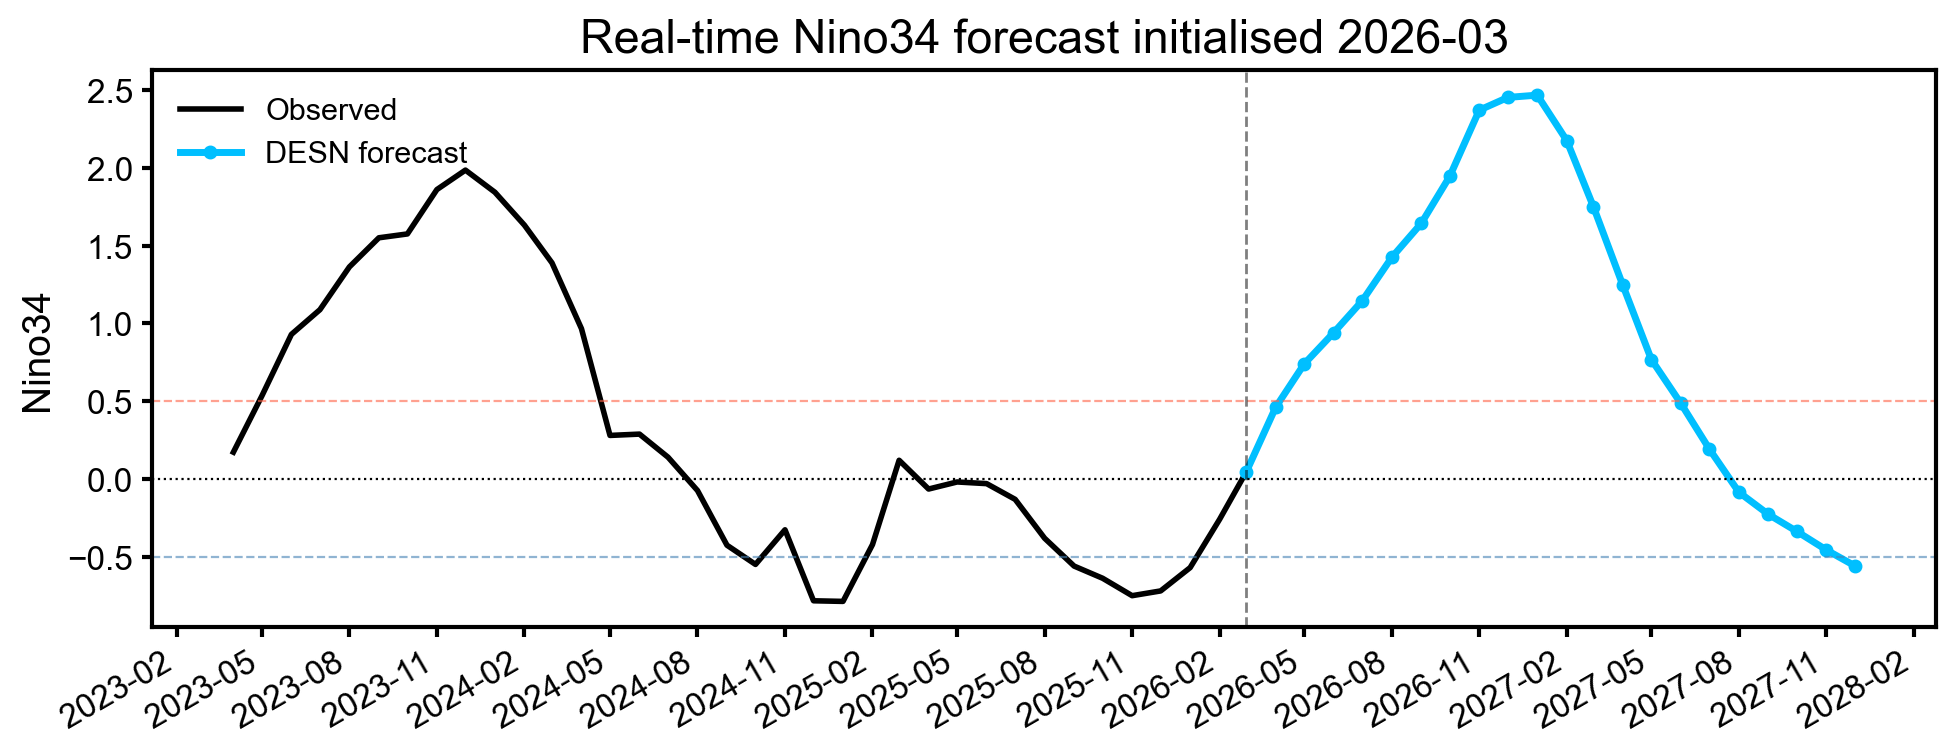

In [13]:
# ── Plot real-time forecast ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

mode_idx = climate_modes.index(PLOT_MODE)

fig, ax = plt.subplots(figsize=(10, 4))

# ── Historical observed (last 36 months before forecast) ──────────────────────
n_hist = 36
hist_times = pd.DatetimeIndex([pd.Timestamp(str(t)[:10]) for t in time_full[-n_hist:]])
hist_vals  = TS_full[-n_hist:, mode_idx]
ax.plot(hist_times, hist_vals, color='black', linewidth=2, label='Observed')

# ── DESN ensemble mean forecast ───────────────────────────────────────────────
ax.plot(forecast_times, rt_mean[:, mode_idx],
        color='deepskyblue', linewidth=2.5, marker='o', markersize=4,
        label='DESN forecast')

# ── Ensemble spread (±1 std) ──────────────────────────────────────────────────
if NMEMBERS > 1:
    ax.fill_between(
        forecast_times,
        rt_mean[:, mode_idx] - rt_std[:, mode_idx],
        rt_mean[:, mode_idx] + rt_std[:, mode_idx],
        color='deepskyblue', alpha=0.2, label='±1 std')

# ── Decorations ───────────────────────────────────────────────────────────────
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.axhline(0.5,  color='tomato',     linewidth=0.8, linestyle='--', alpha=0.6)
ax.axhline(-0.5, color='steelblue',  linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(pd.Timestamp(REALTIME_START), color='black', linewidth=1, linestyle='--', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel(PLOT_MODE)
ax.set_title(f'Real-time {PLOT_MODE} forecast initialised {REALTIME_START[:7]}')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()